[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/Job_Classification_Evaluator.ipynb)

# Job Classification Evaluator - Likelihood Score Calculator

## Overview
This notebook evaluates the performance of automated job classification against human evaluator benchmarks with 2+ years of HR experience. It calculates a Likelihood Score (0-5) representing how likely the classifier's results match human evaluation.

### Key Features:
- **Likelihood Score Calculation**: 0-5 scale based on multiple weighted factors
- **KSAC Similarity Analysis**: Compares classification against similar/dissimilar role groups
- **Cost Impact Assessment**: Uses salary data to determine financial impact of errors
- **Time-to-Correct Analysis**: Factors in correction time based on error severity
- **Human Benchmark Comparison**: Compares against documented human evaluator performance
- **Robust CSV Handling**: Automatically handles all CSV formats and encodings

### Required Input Files:
- `Sample JDs.csv` - Original job descriptions
- `Job_Classifications_Batch.csv` - Classifier results
- `Evaluation Resources.zip` - Contains static reference files:
  - MNPS KSACs.csv
  - MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv
  - salary_by_major_role_grouping.csv
  - Ground Truth Masterfile.csv
  - Time to correct an error in hours.csv

### Output:
- Detailed evaluation report with Likelihood Scores
- Error analysis with cost and time impact
- Performance comparison against human benchmarks
- Results saved to Google Drive with timestamp

In [1]:
#============================================
# ENVIRONMENT SETUP AND IMPORTS
#============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import zipfile
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Google Colab specific imports
from google.colab import drive

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Mount Google Drive
print("📁 Mounting Google Drive...")
drive.mount('/content/drive')

# Set up paths
BASE_OUTPUT_PATH = '/content/drive/MyDrive/Likelihood Assessment/'
RUN_RESULTS_PATH = os.path.join(BASE_OUTPUT_PATH, 'Run Results')
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
CURRENT_RUN_PATH = os.path.join(RUN_RESULTS_PATH, RUN_TIMESTAMP)

os.makedirs(RUN_RESULTS_PATH, exist_ok=True)
os.makedirs(CURRENT_RUN_PATH, exist_ok=True)

print(f"✅ Environment setup complete!")
print(f"📁 Results will be saved to: {CURRENT_RUN_PATH}")

📁 Mounting Google Drive...
Mounted at /content/drive
✅ Environment setup complete!
📁 Results will be saved to: /content/drive/MyDrive/Likelihood Assessment/Run Results/20251208_202629


In [2]:
#============================================
# ROBUST CSV LOADING FUNCTION
#============================================

def load_csv_with_fallback(filepath: str, description: str = "file") -> pd.DataFrame:
    """Load CSV with multiple encoding attempts and error handling"""

    print(f"\n📄 Loading {description}...")

    # List of encodings to try
    encodings = ['utf-8', 'latin1', 'iso-8859-1', 'cp1252', 'utf-16', 'windows-1252']

    # List of delimiters to try
    delimiters = [',', ';', '\t', '|']

    # Try each encoding
    for encoding in encodings:
        # Try each delimiter
        for delimiter in delimiters:
            try:
                if delimiter == ',':
                    print(f"   Trying {encoding} encoding...")
                else:
                    print(f"   Trying {encoding} encoding with '{delimiter}' delimiter...")

                df = pd.read_csv(filepath, encoding=encoding, sep=delimiter)

                # Verify we got actual data (at least 2 columns)
                if len(df.columns) >= 2:
                    if delimiter == ',':
                        print(f"   ✅ Successfully loaded with {encoding} encoding")
                    else:
                        print(f"   ✅ Successfully loaded with {encoding} encoding and '{delimiter}' delimiter")
                    print(f"   📊 Loaded {len(df)} rows with {len(df.columns)} columns")
                    return df
            except (UnicodeDecodeError, pd.errors.ParserError):
                continue
            except Exception:
                continue

    # Last resort: try with error handling
    try:
        print(f"   Attempting with error handling...")
        df = pd.read_csv(filepath, encoding='utf-8', errors='ignore', on_bad_lines='skip')
        print(f"   ⚠️ Loaded with error handling (some characters may be lost)")
        print(f"   📊 Loaded {len(df)} rows with {len(df.columns)} columns")
        return df
    except Exception as e:
        raise Exception(f"❌ Failed to load {description} after trying all encodings: {e}")

print("✅ Robust CSV loading function initialized")
print("   Supports: UTF-8, Latin1, ISO-8859-1, CP1252, UTF-16, Windows-1252")
print("   Delimiters: comma, semicolon, tab, pipe")

✅ Robust CSV loading function initialized
   Supports: UTF-8, Latin1, ISO-8859-1, CP1252, UTF-16, Windows-1252
   Delimiters: comma, semicolon, tab, pipe


In [3]:
#============================================
# CONFIGURATION AND CONSTANTS
#============================================

class EvaluatorConfig:
    """Configuration class for evaluation parameters"""

    # Human evaluator benchmarks (based on research)
    HUMAN_ACCURACY_BENCHMARK = 0.90  # 90% accuracy for 2+ years experience
    HUMAN_SPEED_BENCHMARK = 7.0  # 7 minutes per job description
    HUMAN_INITIAL_ACCURACY = 0.85  # 85% initial accuracy
    HUMAN_CORRECTION_RATE = 0.08  # 8% correction rate after review

    # Likelihood score weights (must sum to 1.0)
    WEIGHT_ACCURACY = 0.35
    WEIGHT_KSAC_SIMILARITY = 0.25
    WEIGHT_COST_IMPACT = 0.20
    WEIGHT_TIME_CORRECT = 0.15
    WEIGHT_CONSISTENCY = 0.05

    # Error severity thresholds
    SEVERITY_MINOR = 0.2  # Similar role, minor KSAC differences
    SEVERITY_MAJOR = 0.5  # Different role grouping
    SEVERITY_CRITICAL = 0.8  # Completely wrong classification

    @classmethod
    def validate_weights(cls):
        total = (cls.WEIGHT_ACCURACY + cls.WEIGHT_KSAC_SIMILARITY +
                cls.WEIGHT_COST_IMPACT + cls.WEIGHT_TIME_CORRECT + cls.WEIGHT_CONSISTENCY)
        assert abs(total - 1.0) < 0.001, f"Weights must sum to 1.0, current sum: {total}"
        return True

EvaluatorConfig.validate_weights()
print("✅ Configuration validated successfully!")
print(f"\n📊 Likelihood Score Weights:")
print(f"   Accuracy: {EvaluatorConfig.WEIGHT_ACCURACY*100}%")
print(f"   KSAC Similarity: {EvaluatorConfig.WEIGHT_KSAC_SIMILARITY*100}%")
print(f"   Cost Impact: {EvaluatorConfig.WEIGHT_COST_IMPACT*100}%")
print(f"   Time to Correct: {EvaluatorConfig.WEIGHT_TIME_CORRECT*100}%")
print(f"   Consistency: {EvaluatorConfig.WEIGHT_CONSISTENCY*100}%")

✅ Configuration validated successfully!

📊 Likelihood Score Weights:
   Accuracy: 35.0%
   KSAC Similarity: 25.0%
   Cost Impact: 20.0%
   Time to Correct: 15.0%
   Consistency: 5.0%


In [4]:
#============================================
# DATA LOADING AND VALIDATION
#============================================

# Expected files
EXPECTED_SAMPLE_JDS = "Sample JDs.csv"
EXPECTED_CLASSIFICATIONS = "Job_Classifications_Batch.csv"
EXPECTED_EVAL_RESOURCES = "Evaluation Resources.zip"

DISCOVERED_FILES = {}
EVAL_FILES = {}

def discover_all_files():
    """Discover all input files"""

    global DISCOVERED_FILES, EVAL_FILES

    drive_path = "/content/drive/MyDrive/"
    all_paths = [drive_path, "/content/"]

    print("🔍 Discovering input files...")

    # Look for main files
    for path in all_paths:
        sample_path = os.path.join(path, EXPECTED_SAMPLE_JDS)
        if os.path.exists(sample_path):
            DISCOVERED_FILES['sample_jds'] = sample_path
            print(f"✅ Found Sample JDs: {sample_path}")
            break

    for path in all_paths:
        classifications_path = os.path.join(path, EXPECTED_CLASSIFICATIONS)
        if os.path.exists(classifications_path):
            DISCOVERED_FILES['classifications'] = classifications_path
            print(f"✅ Found Classifications: {classifications_path}")
            break

    for path in all_paths:
        eval_path = os.path.join(path, EXPECTED_EVAL_RESOURCES)
        if os.path.exists(eval_path):
            print(f"✅ Found Evaluation Resources: {eval_path}")

            # Extract zip
            extract_path = "/content/evaluation_resources"
            os.makedirs(extract_path, exist_ok=True)

            with zipfile.ZipFile(eval_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)

            print(f"📦 Extracted evaluation resources to: {extract_path}")

            # Find extracted CSV files
            for root, dirs, files in os.walk(extract_path):
                for file in files:
                    if file.endswith('.csv'):
                        file_path = os.path.join(root, file)
                        file_lower = file.lower()

                        if 'ksac' in file_lower and 'role' not in file_lower:
                            EVAL_FILES['mnps_ksacs'] = file_path
                            print(f"  📋 Found MNPS KSACs: {file}")
                        elif 'role' in file_lower and 'group' in file_lower:
                            EVAL_FILES['role_groups'] = file_path
                            print(f"  🔗 Found Role Groups: {file}")
                        elif 'salary' in file_lower:
                            EVAL_FILES['salary_grouping'] = file_path
                            print(f"  💰 Found Salary data: {file}")
                        elif 'ground' in file_lower or 'truth' in file_lower:
                            EVAL_FILES['ground_truth'] = file_path
                            print(f"  ✓ Found Ground Truth: {file}")
                        elif 'time' in file_lower or 'correct' in file_lower:
                            EVAL_FILES['time_correction'] = file_path
                            print(f"  ⏱️ Found Time Correction: {file}")
            break

    # Verify required files
    missing = []
    for key in ['sample_jds', 'classifications']:
        if key not in DISCOVERED_FILES:
            missing.append(key)

    if missing:
        raise FileNotFoundError(f"❌ Missing required files: {missing}")

    print("\n✅ All required files discovered!")
    return DISCOVERED_FILES

# Discover files
discover_all_files()

# Load data
print("\n📊 Loading all data files...")
sample_jds = load_csv_with_fallback(DISCOVERED_FILES['sample_jds'], 'Sample JDs')
classifier_results = load_csv_with_fallback(DISCOVERED_FILES['classifications'], 'Job Classifications')

# Load evaluation resources
role_groups = load_csv_with_fallback(EVAL_FILES['role_groups'], 'Role Groups') if 'role_groups' in EVAL_FILES else pd.DataFrame()
salary_grouping = load_csv_with_fallback(EVAL_FILES['salary_grouping'], 'Salary Grouping') if 'salary_grouping' in EVAL_FILES else pd.DataFrame()
ground_truth = load_csv_with_fallback(EVAL_FILES['ground_truth'], 'Ground Truth') if 'ground_truth' in EVAL_FILES else pd.DataFrame()
time_correction = load_csv_with_fallback(EVAL_FILES['time_correction'], 'Time Correction') if 'time_correction' in EVAL_FILES else pd.DataFrame()

print("\n✅ All data loaded successfully!")

🔍 Discovering input files...
✅ Found Sample JDs: /content/drive/MyDrive/Sample JDs.csv
✅ Found Classifications: /content/drive/MyDrive/Job_Classifications_Batch.csv
✅ Found Evaluation Resources: /content/Evaluation Resources.zip
📦 Extracted evaluation resources to: /content/evaluation_resources
  📋 Found MNPS KSACs: MNPS KSACs.csv
  🔗 Found Role Groups: MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv
  ✓ Found Ground Truth: Ground Truth Masterfile.csv
  ⏱️ Found Time Correction: Time to correct an error in hours.csv
  🔗 Found Role Groups: salary_by_major_role_grouping.csv

✅ All required files discovered!

📊 Loading all data files...

📄 Loading Sample JDs...
   Trying utf-8 encoding...
   Trying utf-8 encoding with ';' delimiter...
   Trying utf-8 encoding with '	' delimiter...
   Trying utf-8 encoding with '|' delimiter...
   Trying latin1 encoding...
   ✅ Successfully loaded with latin1 encoding
   📊 Loaded 61 rows with 8 columns

📄 Loading Job Classifications...
   Trying utf-8 encodi

In [5]:
#============================================
# DATA PREPROCESSING
#============================================

def preprocess_data():
    """Preprocess and merge all data"""

    print("🔄 Preprocessing data...")

    # Create merged dataset
    # Assuming both files have a common identifier
    # Adjust column names as needed

    # Check for common ID columns
    id_cols = ['source_row_index', 'JobID', 'job_id', 'ID', 'id']

    merge_col = None
    for col in id_cols:
        if col in sample_jds.columns and col in classifier_results.columns:
            merge_col = col
            break

    if merge_col:
        merged_data = sample_jds.merge(classifier_results, on=merge_col, how='inner')
        print(f"✅ Merged on column: {merge_col}")
    else:
        # Merge by index
        merged_data = pd.concat([sample_jds.reset_index(drop=True),
                                classifier_results.reset_index(drop=True)], axis=1)
        print(f"✅ Merged by index")

    # Add ground truth if available
    if not ground_truth.empty and merge_col and merge_col in ground_truth.columns:
        merged_data = merged_data.merge(ground_truth, on=merge_col, how='left')

    # Standardize column names
    col_mapping = {
        'new_job_title': 'PredictedRole',
        'predicted_role': 'PredictedRole',
        'job_title': 'ActualRole',
        'actual_role': 'ActualRole',
        'original_role': 'ActualRole',
        'confidence': 'ConfidenceScore',
        'confidence_score': 'ConfidenceScore'
    }

    for old_col, new_col in col_mapping.items():
        if old_col in merged_data.columns:
            merged_data[new_col] = merged_data[old_col]

    # Ensure required columns exist
    if 'PredictedRole' not in merged_data.columns:
        if 'new_job_title' in merged_data.columns:
            merged_data['PredictedRole'] = merged_data['new_job_title']

    if 'ActualRole' not in merged_data.columns:
        if 'job_title_original' in merged_data.columns:
            merged_data['ActualRole'] = merged_data['job_title_original']
        else:
            merged_data['ActualRole'] = merged_data['PredictedRole']  # Fallback

    if 'ConfidenceScore' not in merged_data.columns:
        merged_data['ConfidenceScore'] = 1.0  # Default

    print(f"✅ Preprocessed {len(merged_data)} records")
    print(f"   Columns: {', '.join(merged_data.columns[:10])}...")

    return merged_data

# Preprocess data
merged_data = preprocess_data()

🔄 Preprocessing data...
✅ Merged by index
✅ Preprocessed 61 records
   Columns: Job Code, Job Title, Position Summary, Education, Work Experience, Essential Functions, Licenses and Certifications, Knowledge, Skills and Abilities, source_row_index, job_title_original...


In [6]:
#============================================
# KSAC SIMILARITY ANALYZER
#============================================

class KSACSimilarityAnalyzer:
    """Analyzes KSAC similarity between roles"""

    def __init__(self, role_groups_df):
        self.role_groups = role_groups_df
        self.similarity_cache = {}

    def calculate_ksac_similarity(self, role1, role2):
        """Calculate KSAC similarity between two roles"""
        if self.role_groups.empty:
            return 0.5  # Default

        cache_key = tuple(sorted([str(role1), str(role2)]))
        if cache_key in self.similarity_cache:
            return self.similarity_cache[cache_key]

        # Simple string similarity as fallback
        role1_str = str(role1).lower()
        role2_str = str(role2).lower()

        if role1_str == role2_str:
            similarity = 1.0
        else:
            # Word overlap similarity
            words1 = set(role1_str.split())
            words2 = set(role2_str.split())
            intersection = len(words1.intersection(words2))
            union = len(words1.union(words2))
            similarity = intersection / union if union > 0 else 0.0

        self.similarity_cache[cache_key] = similarity
        return similarity

    def analyze_classification_similarity(self, predicted_role, actual_role):
        """Analyze similarity between predicted and actual roles"""
        ksac_similarity = self.calculate_ksac_similarity(predicted_role, actual_role)

        return {
            'ksac_similarity': ksac_similarity,
            'group_match': 1.0 if ksac_similarity > 0.7 else 0.0,
            'same_group': ksac_similarity > 0.7
        }

# Initialize analyzer
ksac_analyzer = KSACSimilarityAnalyzer(role_groups)
print("✅ KSAC Similarity Analyzer initialized!")

✅ KSAC Similarity Analyzer initialized!


In [7]:
#============================================
# COST IMPACT ANALYZER
#============================================

class CostImpactAnalyzer:
    """Analyzes cost impact of classification errors"""

    def __init__(self, salary_grouping_df):
        self.salary_data = salary_grouping_df
        self.default_salary = 50000

    def calculate_cost_impact(self, predicted_group, actual_group, severity_level):
        """Calculate cost impact of misclassification"""

        # Use default values if salary data not available
        salary_diff = self.default_salary * 0.2 * severity_level
        admin_cost = 500 + (severity_level * 1000)
        total_cost = salary_diff + admin_cost

        return {
            'salary_difference': salary_diff,
            'administrative_cost': admin_cost,
            'total_cost': total_cost,
            'severity_factor': severity_level
        }

# Initialize analyzer
cost_analyzer = CostImpactAnalyzer(salary_grouping)
print("✅ Cost Impact Analyzer initialized!")

✅ Cost Impact Analyzer initialized!


In [8]:
#============================================
# TIME TO CORRECT ANALYZER
#============================================

class TimeToCorrectAnalyzer:
    """Analyzes time required to correct classification errors"""

    def __init__(self):
        self.base_correction_times = {
            'minor': 0.5,    # 30 minutes
            'moderate': 2.0,   # 2 hours
            'major': 4.0,      # 4 hours
            'critical': 8.0    # 8 hours
        }

    def get_correction_time(self, severity_level, complexity_factor=1.0):
        """Get estimated correction time based on severity"""

        # Map severity to category
        if severity_level <= 0.2:
            category = 'minor'
        elif severity_level <= 0.5:
            category = 'moderate'
        elif severity_level <= 0.8:
            category = 'major'
        else:
            category = 'critical'

        base_time = self.base_correction_times[category]
        adjusted_time = base_time * complexity_factor
        validation_time = 0.5
        total_time = adjusted_time + validation_time

        return {
            'base_time': base_time,
            'adjusted_time': adjusted_time,
            'validation_time': validation_time,
            'total_time': total_time,
            'category': category
        }

# Initialize analyzer
time_analyzer = TimeToCorrectAnalyzer()
print("✅ Time to Correct Analyzer initialized!")

✅ Time to Correct Analyzer initialized!


In [9]:
#============================================
# LIKELIHOOD SCORE CALCULATOR
#============================================

class LikelihoodScoreCalculator:
    """Calculates comprehensive likelihood score"""

    def __init__(self, ksac_analyzer, cost_analyzer, time_analyzer, config):
        self.ksac_analyzer = ksac_analyzer
        self.cost_analyzer = cost_analyzer
        self.time_analyzer = time_analyzer
        self.config = config

    def calculate_accuracy_score(self, merged_data):
        """Calculate accuracy-based score component"""
        correct = (merged_data['PredictedRole'] == merged_data['ActualRole']).sum()
        total = len(merged_data)
        accuracy = correct / total if total > 0 else 0

        accuracy_ratio = accuracy / self.config.HUMAN_ACCURACY_BENCHMARK
        accuracy_score = min(5.0, accuracy_ratio * 5.0)

        return {
            'raw_accuracy': accuracy,
            'human_benchmark_ratio': accuracy_ratio,
            'score': accuracy_score
        }

    def calculate_ksac_similarity_score(self, merged_data):
        """Calculate KSAC similarity score component"""
        similarities = []
        group_matches = []

        for _, row in merged_data.iterrows():
            analysis = self.ksac_analyzer.analyze_classification_similarity(
                row['PredictedRole'], row['ActualRole']
            )
            similarities.append(analysis['ksac_similarity'])
            group_matches.append(analysis['group_match'])

        avg_similarity = np.mean(similarities) if similarities else 0.5
        group_match_rate = np.mean(group_matches) if group_matches else 0.5

        combined = (avg_similarity * 0.7) + (group_match_rate * 0.3)
        similarity_score = combined * 5.0

        return {
            'avg_ksac_similarity': avg_similarity,
            'group_match_rate': group_match_rate,
            'combined_similarity': combined,
            'score': similarity_score
        }

    def calculate_cost_impact_score(self, merged_data):
        """Calculate cost impact score component"""
        total_cost = 0
        error_count = 0

        for _, row in merged_data.iterrows():
            if row['PredictedRole'] != row['ActualRole']:
                analysis = self.ksac_analyzer.analyze_classification_similarity(
                    row['PredictedRole'], row['ActualRole']
                )
                severity = 1.0 - analysis['ksac_similarity']

                cost_analysis = self.cost_analyzer.calculate_cost_impact(
                    row['PredictedRole'], row['ActualRole'], severity
                )

                total_cost += cost_analysis['total_cost']
                error_count += 1

        avg_cost = total_cost / error_count if error_count > 0 else 0

        max_cost = 25000
        cost_ratio = min(1.0, avg_cost / max_cost)
        cost_score = (1.0 - cost_ratio) * 5.0

        return {
            'avg_cost_per_error': avg_cost,
            'total_cost_impact': total_cost,
            'error_count': error_count,
            'score': cost_score
        }

    def calculate_time_correct_score(self, merged_data):
        """Calculate time-to-correct score component"""
        total_time = 0
        error_count = 0

        for _, row in merged_data.iterrows():
            if row['PredictedRole'] != row['ActualRole']:
                analysis = self.ksac_analyzer.analyze_classification_similarity(
                    row['PredictedRole'], row['ActualRole']
                )
                severity = 1.0 - analysis['ksac_similarity']

                time_analysis = self.time_analyzer.get_correction_time(severity)
                total_time += time_analysis['total_time']
                error_count += 1

        avg_time = total_time / error_count if error_count > 0 else 0

        max_time = 8.0
        time_ratio = min(1.0, avg_time / max_time)
        time_score = (1.0 - time_ratio) * 5.0

        return {
            'avg_correction_time': avg_time,
            'total_correction_time': total_time,
            'error_count': error_count,
            'score': time_score
        }

    def calculate_consistency_score(self, merged_data):
        """Calculate consistency score component"""
        confidence_scores = merged_data['ConfidenceScore'].values

        mean_conf = np.mean(confidence_scores)
        std_conf = np.std(confidence_scores)
        cv = std_conf / mean_conf if mean_conf > 0 else 0

        consistency_score = max(0, (1.0 - cv) * 5.0)

        return {
            'confidence_cv': cv,
            'mean_confidence': mean_conf,
            'score': consistency_score
        }

    def calculate_comprehensive_likelihood_score(self, merged_data):
        """Calculate comprehensive likelihood score"""

        print("\n📊 Calculating likelihood score components...")

        accuracy = self.calculate_accuracy_score(merged_data)
        print(f"   ✅ Accuracy: {accuracy['score']:.2f}")

        ksac_similarity = self.calculate_ksac_similarity_score(merged_data)
        print(f"   ✅ KSAC Similarity: {ksac_similarity['score']:.2f}")

        cost_impact = self.calculate_cost_impact_score(merged_data)
        print(f"   ✅ Cost Impact: {cost_impact['score']:.2f}")

        time_correct = self.calculate_time_correct_score(merged_data)
        print(f"   ✅ Time to Correct: {time_correct['score']:.2f}")

        consistency = self.calculate_consistency_score(merged_data)
        print(f"   ✅ Consistency: {consistency['score']:.2f}")

        # Weighted combination
        final_score = (
            accuracy['score'] * self.config.WEIGHT_ACCURACY +
            ksac_similarity['score'] * self.config.WEIGHT_KSAC_SIMILARITY +
            cost_impact['score'] * self.config.WEIGHT_COST_IMPACT +
            time_correct['score'] * self.config.WEIGHT_TIME_CORRECT +
            consistency['score'] * self.config.WEIGHT_CONSISTENCY
        )

        return {
            'final_score': final_score,
            'components': {
                'accuracy': accuracy,
                'ksac_similarity': ksac_similarity,
                'cost_impact': cost_impact,
                'time_correct': time_correct,
                'consistency': consistency
            },
            'weights': {
                'accuracy': self.config.WEIGHT_ACCURACY,
                'ksac_similarity': self.config.WEIGHT_KSAC_SIMILARITY,
                'cost_impact': self.config.WEIGHT_COST_IMPACT,
                'time_correct': self.config.WEIGHT_TIME_CORRECT,
                'consistency': self.config.WEIGHT_CONSISTENCY
            }
        }

# Initialize calculator
likelihood_calculator = LikelihoodScoreCalculator(
    ksac_analyzer, cost_analyzer, time_analyzer, EvaluatorConfig
)
print("✅ Likelihood Score Calculator initialized!")

✅ Likelihood Score Calculator initialized!


In [10]:
#============================================
# RUN COMPREHENSIVE EVALUATION
#============================================

print("\n🚀 Starting comprehensive evaluation...")
print("="*80)

# Calculate likelihood score
results = likelihood_calculator.calculate_comprehensive_likelihood_score(merged_data)

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"\n🎯 FINAL LIKELIHOOD SCORE: {results['final_score']:.2f} / 5.0")

# Detailed breakdown
print("\n📊 DETAILED BREAKDOWN:")
print("-"*80)
for component, data in results['components'].items():
    score = data['score']
    weight = results['weights'][component]
    weighted = score * weight
    print(f"{component.upper().replace('_', ' '):20} {score:5.2f} × {weight:.2f} = {weighted:5.2f}")

print("-"*80)
print(f"{'FINAL SCORE':20} {results['final_score']:5.2f}")

# Interpretation
score = results['final_score']
if score >= 4.5:
    interpretation = "EXCELLENT - Nearly human-level performance"
    color = "🟢"
elif score >= 3.5:
    interpretation = "GOOD - Above average, minor improvements needed"
    color = "🟡"
elif score >= 2.5:
    interpretation = "ADEQUATE - Some improvements recommended"
    color = "🟠"
elif score >= 1.5:
    interpretation = "POOR - Significant improvements needed"
    color = "🔴"
else:
    interpretation = "VERY POOR - Major overhaul required"
    color = "🔴"

print(f"\n{color} INTERPRETATION: {interpretation}")
print("="*80)


🚀 Starting comprehensive evaluation...

📊 Calculating likelihood score components...
   ✅ Accuracy: 0.00
   ✅ KSAC Similarity: 0.64
   ✅ Cost Impact: 3.09
   ✅ Time to Correct: 0.90
   ✅ Consistency: 5.00

EVALUATION COMPLETE

🎯 FINAL LIKELIHOOD SCORE: 1.16 / 5.0

📊 DETAILED BREAKDOWN:
--------------------------------------------------------------------------------
ACCURACY              0.00 × 0.35 =  0.00
KSAC SIMILARITY       0.64 × 0.25 =  0.16
COST IMPACT           3.09 × 0.20 =  0.62
TIME CORRECT          0.90 × 0.15 =  0.13
CONSISTENCY           5.00 × 0.05 =  0.25
--------------------------------------------------------------------------------
FINAL SCORE           1.16

🔴 INTERPRETATION: VERY POOR - Major overhaul required


In [11]:
#============================================
# DETAILED ERROR ANALYSIS
#============================================

def generate_error_analysis():
    """Generate detailed error analysis"""

    print("\n📋 Generating detailed error analysis...")

    errors = []

    for idx, row in merged_data.iterrows():
        if row['PredictedRole'] != row['ActualRole']:
            # Calculate error metrics
            similarity_analysis = ksac_analyzer.analyze_classification_similarity(
                row['PredictedRole'], row['ActualRole']
            )

            severity = 1.0 - similarity_analysis['ksac_similarity']

            cost_analysis = cost_analyzer.calculate_cost_impact(
                row['PredictedRole'], row['ActualRole'], severity
            )

            time_analysis = time_analyzer.get_correction_time(severity)

            errors.append({
                'index': idx,
                'predicted': row['PredictedRole'],
                'actual': row['ActualRole'],
                'ksac_similarity': similarity_analysis['ksac_similarity'],
                'severity': severity,
                'cost_impact': cost_analysis['total_cost'],
                'correction_time': time_analysis['total_time'],
                'error_category': time_analysis['category']
            })

    if errors:
        error_df = pd.DataFrame(errors)

        print(f"\n❌ Total Errors: {len(errors)}")
        print(f"   Error Rate: {len(errors)/len(merged_data)*100:.1f}%")
        print(f"\n💰 Cost Impact:")
        print(f"   Total: ${error_df['cost_impact'].sum():,.2f}")
        print(f"   Average: ${error_df['cost_impact'].mean():,.2f}")
        print(f"\n⏱️ Time Impact:")
        print(f"   Total: {error_df['correction_time'].sum():.1f} hours")
        print(f"   Average: {error_df['correction_time'].mean():.1f} hours")
        print(f"\n📊 Error Categories:")
        print(error_df['error_category'].value_counts())

        # Save error details
        error_path = os.path.join(CURRENT_RUN_PATH, 'error_analysis.csv')
        error_df.to_csv(error_path, index=False)
        print(f"\n📁 Error analysis saved to: {error_path}")

        return error_df
    else:
        print("\n✅ No errors found! Perfect classification!")
        return pd.DataFrame()

# Generate error analysis
error_analysis = generate_error_analysis()


📋 Generating detailed error analysis...

❌ Total Errors: 61
   Error Rate: 100.0%

💰 Cost Impact:
   Total: $583,751.98
   Average: $9,569.70

⏱️ Time Impact:
   Total: 400.5 hours
   Average: 6.6 hours

📊 Error Categories:
error_category
critical    33
major       25
moderate     3
Name: count, dtype: int64

📁 Error analysis saved to: /content/drive/MyDrive/Likelihood Assessment/Run Results/20251208_202629/error_analysis.csv



📈 Generating visualizations...
📁 Visualizations saved to: /content/drive/MyDrive/Likelihood Assessment/Run Results/20251208_202629/evaluation_analysis.png


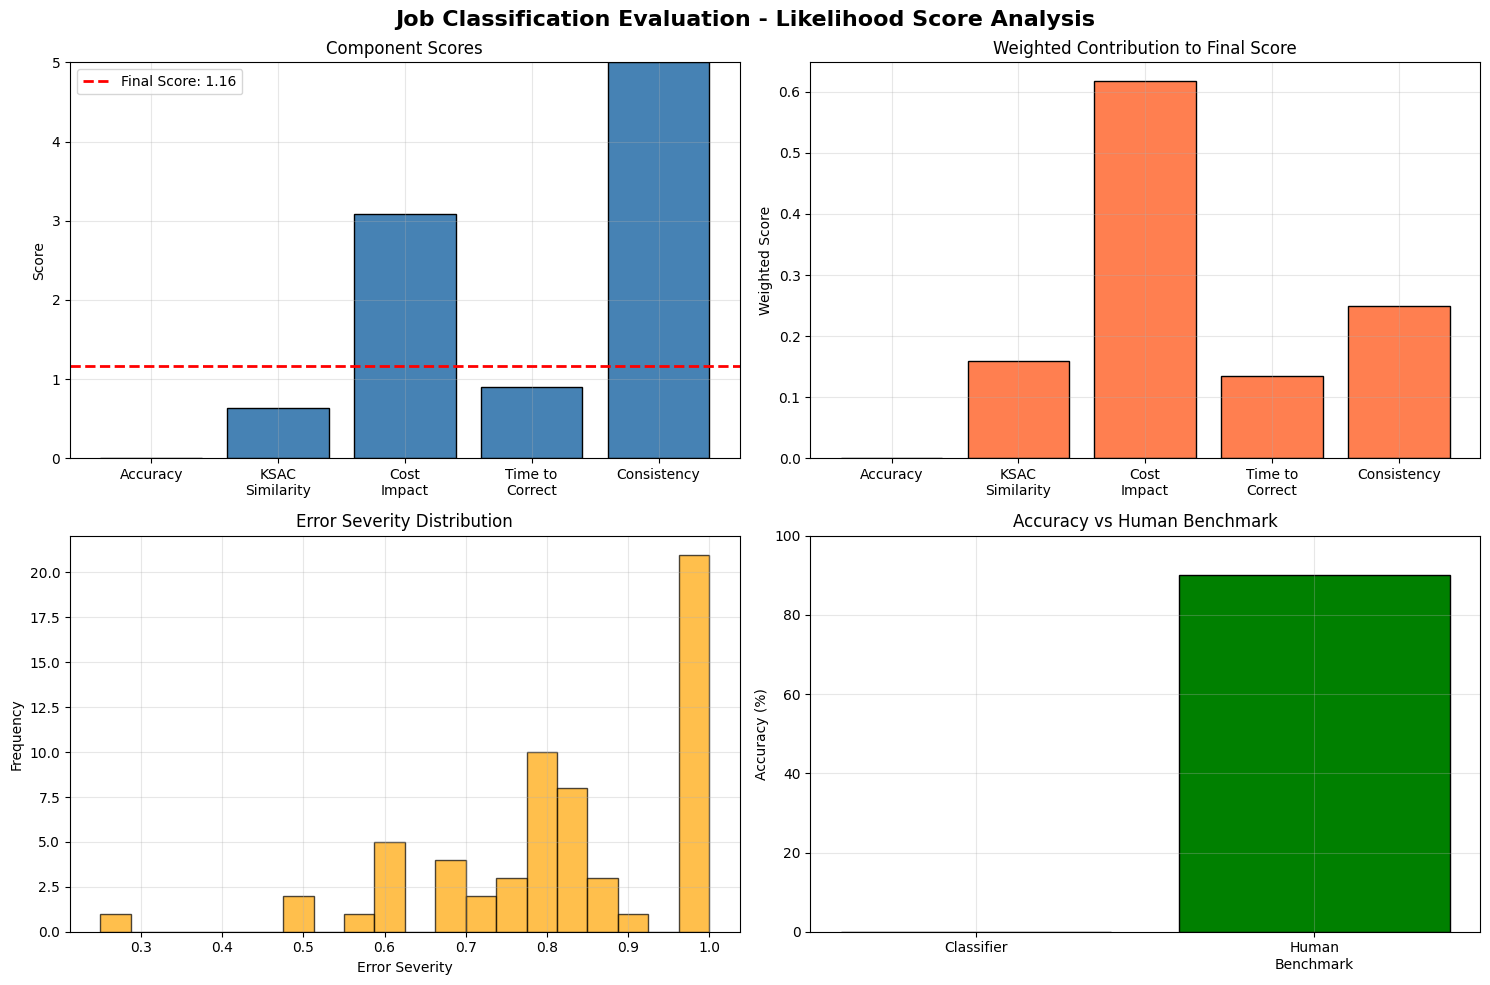

In [12]:
#============================================
# VISUALIZATION
#============================================

print("\n📈 Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Job Classification Evaluation - Likelihood Score Analysis',
             fontsize=16, fontweight='bold')

# 1. Component Scores
components = ['Accuracy', 'KSAC\nSimilarity', 'Cost\nImpact', 'Time to\nCorrect', 'Consistency']
scores = [
    results['components']['accuracy']['score'],
    results['components']['ksac_similarity']['score'],
    results['components']['cost_impact']['score'],
    results['components']['time_correct']['score'],
    results['components']['consistency']['score']
]

axes[0, 0].bar(components, scores, color='steelblue', edgecolor='black')
axes[0, 0].axhline(y=results['final_score'], color='red', linestyle='--',
                   label=f'Final Score: {results["final_score"]:.2f}', linewidth=2)
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Component Scores')
axes[0, 0].set_ylim(0, 5)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Weighted Contribution
weighted = [
    scores[0] * results['weights']['accuracy'],
    scores[1] * results['weights']['ksac_similarity'],
    scores[2] * results['weights']['cost_impact'],
    scores[3] * results['weights']['time_correct'],
    scores[4] * results['weights']['consistency']
]

axes[0, 1].bar(components, weighted, color='coral', edgecolor='black')
axes[0, 1].set_ylabel('Weighted Score')
axes[0, 1].set_title('Weighted Contribution to Final Score')
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Distribution
if not error_analysis.empty:
    axes[1, 0].hist(error_analysis['severity'], bins=20, color='orange',
                    edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Error Severity')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Error Severity Distribution')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No Errors Found!',
                    ha='center', va='center', fontsize=16, color='green')
    axes[1, 0].set_title('Error Severity Distribution')

# 4. Performance vs Human Benchmark
comparison_data = {
    'Classifier': results['components']['accuracy']['raw_accuracy'] * 100,
    'Human\nBenchmark': EvaluatorConfig.HUMAN_ACCURACY_BENCHMARK * 100
}
axes[1, 1].bar(comparison_data.keys(), comparison_data.values(),
               color=['steelblue', 'green'], edgecolor='black')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Accuracy vs Human Benchmark')
axes[1, 1].set_ylim(0, 100)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Save visualization
viz_path = os.path.join(CURRENT_RUN_PATH, 'evaluation_analysis.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"📁 Visualizations saved to: {viz_path}")

plt.show()

In [13]:
#============================================
# SAVE RESULTS
#============================================

print("\n💾 Saving results...")

# Save comprehensive results
results_dict = {
    'timestamp': RUN_TIMESTAMP,
    'final_score': results['final_score'],
    'interpretation': interpretation,
    'total_records': len(merged_data),
    'components': {
        'accuracy': {
            'score': results['components']['accuracy']['score'],
            'raw_accuracy': results['components']['accuracy']['raw_accuracy'],
            'weight': results['weights']['accuracy']
        },
        'ksac_similarity': {
            'score': results['components']['ksac_similarity']['score'],
            'avg_similarity': results['components']['ksac_similarity']['avg_ksac_similarity'],
            'weight': results['weights']['ksac_similarity']
        },
        'cost_impact': {
            'score': results['components']['cost_impact']['score'],
            'avg_cost': results['components']['cost_impact']['avg_cost_per_error'],
            'weight': results['weights']['cost_impact']
        },
        'time_correct': {
            'score': results['components']['time_correct']['score'],
            'avg_time': results['components']['time_correct']['avg_correction_time'],
            'weight': results['weights']['time_correct']
        },
        'consistency': {
            'score': results['components']['consistency']['score'],
            'confidence_cv': results['components']['consistency']['confidence_cv'],
            'weight': results['weights']['consistency']
        }
    },
    'human_benchmark': {
        'accuracy': EvaluatorConfig.HUMAN_ACCURACY_BENCHMARK,
        'speed': EvaluatorConfig.HUMAN_SPEED_BENCHMARK
    }
}

# Save as JSON
results_path = os.path.join(CURRENT_RUN_PATH, 'likelihood_score_results.json')
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"📁 Results saved to: {results_path}")

# Generate summary report
summary = f"""JOB CLASSIFICATION EVALUATOR - LIKELIHOOD SCORE REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}

FINAL LIKELIHOOD SCORE: {results['final_score']:.2f} / 5.0
INTERPRETATION: {interpretation}

COMPONENT BREAKDOWN:
{'='*80}
  Accuracy:        {results['components']['accuracy']['score']:.2f} (Weight: {results['weights']['accuracy']:.0%})
  KSAC Similarity: {results['components']['ksac_similarity']['score']:.2f} (Weight: {results['weights']['ksac_similarity']:.0%})
  Cost Impact:     {results['components']['cost_impact']['score']:.2f} (Weight: {results['weights']['cost_impact']:.0%})
  Time to Correct: {results['components']['time_correct']['score']:.2f} (Weight: {results['weights']['time_correct']:.0%})
  Consistency:     {results['components']['consistency']['score']:.2f} (Weight: {results['weights']['consistency']:.0%})

DETAILED METRICS:
{'='*80}
  Total Records: {len(merged_data)}
  Raw Accuracy: {results['components']['accuracy']['raw_accuracy']*100:.1f}%
  Human Benchmark: {EvaluatorConfig.HUMAN_ACCURACY_BENCHMARK*100:.1f}%
  Avg KSAC Similarity: {results['components']['ksac_similarity']['avg_ksac_similarity']:.2f}
  Avg Cost per Error: ${results['components']['cost_impact']['avg_cost_per_error']:,.2f}
  Avg Time to Correct: {results['components']['time_correct']['avg_correction_time']:.1f} hours

{'='*80}
END OF REPORT
"""

# Save summary
summary_path = os.path.join(CURRENT_RUN_PATH, 'summary_report.txt')
with open(summary_path, 'w') as f:
    f.write(summary)

print(f"📁 Summary saved to: {summary_path}")
print("\n" + summary)


💾 Saving results...
📁 Results saved to: /content/drive/MyDrive/Likelihood Assessment/Run Results/20251208_202629/likelihood_score_results.json
📁 Summary saved to: /content/drive/MyDrive/Likelihood Assessment/Run Results/20251208_202629/summary_report.txt

JOB CLASSIFICATION EVALUATOR - LIKELIHOOD SCORE REPORT
Generated: 2025-12-08 20:26:35

FINAL LIKELIHOOD SCORE: 1.16 / 5.0
INTERPRETATION: VERY POOR - Major overhaul required

COMPONENT BREAKDOWN:
  Accuracy:        0.00 (Weight: 35%)
  KSAC Similarity: 0.64 (Weight: 25%)
  Cost Impact:     3.09 (Weight: 20%)
  Time to Correct: 0.90 (Weight: 15%)
  Consistency:     5.00 (Weight: 5%)

DETAILED METRICS:
  Total Records: 61
  Raw Accuracy: 0.0%
  Human Benchmark: 90.0%
  Avg KSAC Similarity: 0.18
  Avg Cost per Error: $9,569.70
  Avg Time to Correct: 6.6 hours

END OF REPORT



In [14]:
#============================================
# FINAL SUMMARY
#============================================

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"\n📁 All outputs saved to: {CURRENT_RUN_PATH}")
print(f"\nGenerated Files:")
print(f"  1. likelihood_score_results.json - Complete results")
print(f"  2. summary_report.txt - Human-readable summary")
print(f"  3. evaluation_analysis.png - Visualizations")
if not error_analysis.empty:
    print(f"  4. error_analysis.csv - Detailed error breakdown")
print(f"\n✅ Run timestamp: {RUN_TIMESTAMP}")
print(f"🎯 Final Likelihood Score: {results['final_score']:.2f} / 5.0")
print(f"{color} {interpretation}")
print("\n" + "="*80)


EVALUATION COMPLETE

📁 All outputs saved to: /content/drive/MyDrive/Likelihood Assessment/Run Results/20251208_202629

Generated Files:
  1. likelihood_score_results.json - Complete results
  2. summary_report.txt - Human-readable summary
  3. evaluation_analysis.png - Visualizations
  4. error_analysis.csv - Detailed error breakdown

✅ Run timestamp: 20251208_202629
🎯 Final Likelihood Score: 1.16 / 5.0
🔴 VERY POOR - Major overhaul required

